<a href="https://colab.research.google.com/github/mukhammadiev01-1/computer_vision/blob/main/menu_detector_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
print("Menu detector!")

Menu detector!


In [13]:

# ---------------------------
# Import Libraries
# ---------------------------

from google.colab import drive
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2

from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np

In [14]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Define Dataset Path

DATASET_PATH = '/content/drive/MyDrive/food101_dataset'
print('Dataset_path:', DATASET_PATH)

CUSTOM_CLASS_MAPPING = {
    'hamburger': 'hamburger',
    'hot_dog': 'hot_dog',
    'chocolate_cake': 'dessert', # label grouping | class consolidation
    'cheesecake': 'dessert',     # label grouping | class consolidation
    'kebab': 'kebab',
    'pilaf': 'pilaf'
}

CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

print(NUM_CLASSES)
print(CLASS_TO_IDX)


# Compose() - pipeline organization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Image [0 ~ 255] => after Tensor [0.0 ~ 1.0]
# Image (Height, Width, Channels|RGB) => order changes after Tensor (Channels, Height, Width
# Normalize
# Formula: pixel = (pixel - mean) / std

Dataset_path: /content/drive/MyDrive/food101_dataset
5
{'hamburger': 0, 'hot_dog': 1, 'dessert': 2, 'kebab': 3, 'pilaf': 4}


In [16]:
# ============================
# Custom Dataset Class
# ============================

# This class reads our files and passes them to the model. It acts like a bridge.
class FoodDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        # Store image paths
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # print('images_length', len(self.images))
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        # print('image_path', img_path)
        label = self.labels[idx]
        # print('label', label)

        try:
            image = Image.open(img_path)
            if image.mode == "P" or image.mode == "RGBA": # png | gif | RGBA
                image = image.convert("RGBA").convert("RGB")
            else:
              image = image.convert("RGB")
        except (UnidentifiedImageError, OSError):
            print(f"Skipping broken image: {img_path}")
            return self.__getitem__((idx + 1) % len(self.images))

        # Apply transformations if provided
        if self.transform:
            image = self.transform(image)

        # Return (tuple) transformed image and its label
        return image, label

In [17]:
# ============================
# Gather and Split Data
# ============================

all_images = []

for original_class, mapped_class in CUSTOM_CLASS_MAPPING.items():
    class_path = os.path.join(DATASET_PATH, original_class) # /content/drive/MyDrive/food101_dataset/hamburger or kebab or pilaf etc.
    print('class_path:', class_path)

    if not os.path.exists(class_path):
        print(f"Warning: {class_path} not found")
        continue

    for img in os.listdir(class_path):
        if img.endswith(('.jpg', '.jpeg', '.png')):
            full_path = os.path.join(class_path, img) # /content/drive/MyDrive/food101_dataset/hamburger/100057.jpg
            all_images.append((full_path, CLASS_TO_IDX[mapped_class]))

np.random.shuffle(all_images)

split = int(0.8 * len(all_images))
train_data = all_images[:split]
val_data = all_images[split:]

train_images, train_labels = zip(*train_data)
val_images, val_labels = zip(*val_data)

# print('all_images:', all_images)

dataset = FoodDataset(train_images, train_labels)
print(len(dataset))
img, lbl = dataset[0]

class_path: /content/drive/MyDrive/food101_dataset/hamburger
class_path: /content/drive/MyDrive/food101_dataset/hot_dog
class_path: /content/drive/MyDrive/food101_dataset/chocolate_cake
class_path: /content/drive/MyDrive/food101_dataset/cheesecake
class_path: /content/drive/MyDrive/food101_dataset/kebab
class_path: /content/drive/MyDrive/food101_dataset/pilaf
3326


In [18]:
train_dataset = FoodDataset(train_images, train_labels, transform=transform)
val_dataset = FoodDataset(val_images, val_labels, transform=transform)

In [19]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2) # thread | parallel loading for speed
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [20]:
# PRETRAINED  - FINE TUNING

model = mobilenet_v2(weights='IMAGENET1K_V1') # pretrained model | lightweight | CNN | 1000 class | million
# FINE-TUNING => add our dataset to the above pretrained model
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES) # FINE-TUNING | backbone | model layer freeze



In [21]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device', device)
model = model.to(device)

device cuda


In [22]:
# Lost functions and Optimizers

criterion = nn.CrossEntropyLoss() # Loss Function | '70%' burger, '30%' pilaf
optimizer = optim.Adam(model.parameters(), lr=0.001) # weight
torch.backends.cudnn.benchmark = True # Benchmark Setting | 10%~20% speed increase | Trick

# print('criterion', criterion)
# print('optimizer', optimizer)


In [11]:
# ============================
# Training Loop
# ============================

NUM_EPOCHS = 10
best_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    model.train() # train mode
    running_loss = 0.0
    for images, labels in train_loader: # Forward and Backward(Backpropagation)
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad() # zero the gradient
      outputs = model(images) # Forward Pass | Dog | 5 Classes
      loss = criterion(outputs, labels) # Calculate Loss
      loss.backward()
      optimizer.step() # Adam optimizer
      running_loss += loss.item() # Track Loss

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total # Calculate Validation Accuracy
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_acc:.2f}%")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), "/content/menu_detector.pth")
        print("Saved new best model!")



Epoch [1/10] Loss: 0.5593, Val Accuracy: 86.06%
Saved new best model!
Epoch [2/10] Loss: 0.3031, Val Accuracy: 86.78%
Saved new best model!
Epoch [3/10] Loss: 0.2236, Val Accuracy: 81.01%
Epoch [4/10] Loss: 0.2347, Val Accuracy: 91.23%
Saved new best model!
Epoch [5/10] Loss: 0.1502, Val Accuracy: 89.66%
Epoch [6/10] Loss: 0.1524, Val Accuracy: 89.54%
Epoch [7/10] Loss: 0.1443, Val Accuracy: 85.94%
Epoch [8/10] Loss: 0.1280, Val Accuracy: 88.34%
Epoch [9/10] Loss: 0.1268, Val Accuracy: 90.26%
Epoch [10/10] Loss: 0.0963, Val Accuracy: 86.30%


# **menu_detector model usage**

device: cuda
Upload one or more images of of your food:


Saving picture.jpeg to picture.jpeg


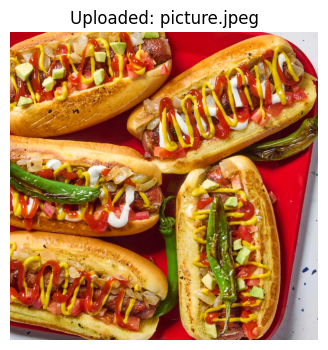

Prediction:
  ✅ hot_dog: 99.24%
  ✅ pilaf: 0.68%
  ✅ kebab: 0.07%
  ✅ hamburger: 0.02%


In [26]:
# ----------------------------------------
# Required Imports
# ----------------------------------------
import torch
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
from PIL import Image
from google.colab import files
import io
import matplotlib.pyplot as plt

# ----------------------------------------
# Define Semantic Classes
# ----------------------------------------
CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']  # Must match training order
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}

# ----------------------------------------
# Transform for Uploaded Images (no augmentations!)
# ----------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ----------------------------------------
# Load Model
# ----------------------------------------

model = mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load('/content/menu_detector.pth', map_location='cpu'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

model = model.to(device)
model.eval() # Here we are not training. We are TESTING our model

# ----------------------------------------
# Upload & Predict - # This section is only designed for Google Colab
# ----------------------------------------

print("Upload one or more images of of your food:")
uploaded = files.upload()

for image_name in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[image_name])).convert('RGB')

    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Uploaded: {image_name}')
    plt.show()

    # Predict
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)[0]
        topk = torch.topk(probs, 4)

    print("Prediction:")
    for i in range(topk.indices.size(0)):
        label = CLASSES[topk.indices[i]]
        confidence = topk.values[i].item() * 100
        print(f"  ✅ {label}: {confidence:.2f}%")